# DMart Retail Analytics — Python Analysis

## Project Overview

This project analyzes DMart retail data to identify insights related to:

- Sales performance
- Product and category performance
- Brand performance
- Pricing and discounts
- Inventory management
- Customer demographics
- Payment methods and status
- Store performance
- Statistical patterns and outliers

The analysis is performed using Python and focuses on
exploratory data analysis, data cleaning, feature engineering,
statistical analysis, and business insights.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset

The project uses multiple DMart datasets covering:

- Sales Transactions
- Customers
- Inventory
- Payments
- Stores
- Suppliers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Display settings configured successfully!")

Display settings configured successfully!


## 1. Data Loading

The DMart project contains six datasets representing different
business areas.

The datasets will be loaded into separate Pandas DataFrames
for analysis.

In [ ]:
customers = pd.read_csv("../Customers.csv")
inventory = pd.read_csv("../Inventory.csv")
payments = pd.read_csv("../Payments.csv")
stores = pd.read_csv("../Stores.csv")
suppliers = pd.read_csv("../Suppliers.csv")
sales = pd.read_csv("../sales_transactions_cleaned.csv")

print("All DMart datasets loaded successfully!")

All DMart datasets loaded successfully!


## 2. Dataset Overview

Before performing any analysis, we will examine the size and
structure of each dataset.

This helps us understand the available data and identify the
main analytical areas.

In [ ]:
datasets = {
    "Sales Transactions": sales,
    "Customers": customers,
    "Inventory": inventory,
    "Payments": payments,
    "Stores": stores,
    "Suppliers": suppliers
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Sales Transactions: 5,189 rows × 7 columns
Customers: 1,000 rows × 8 columns
Inventory: 5,000 rows × 7 columns
Payments: 500 rows × 5 columns
Stores: 20 rows × 8 columns
Suppliers: 40 rows × 8 columns


### 2.1 Sales Transactions

The Sales Transactions dataset contains product-level
transaction information such as product name, brand,
price, discounted price, quantity, and category.

In [ ]:
sales.head()

,sales_transaction_id,Product_Name,Brand,Price,Discounted_Price,Quantity,Category
0,1,Premia Badam (Almonds),Premia,451.0,329.0,500 gm,Dry Fruits
1,2,Premia Badam (Almonds),Premia,109.0,85.0,100 gm,Dry Fruits
2,3,Premia Badam (Almonds),Premia,202.0,175.0,200 gm,Dry Fruits
3,4,Nutraj California Almonds (Badam),Nutraj,599.0,349.0,500 gm,Dry Fruits
4,5,Nutraj California Almonds (Badam),Nutraj,1549.0,659.0,1 kg,Dry Fruits


### 2.2 Dataset Dimensions

Let's verify the number of rows and columns in every dataset.

In [ ]:
print("Customers:", customers.shape)
print("Inventory:", inventory.shape)
print("Payments:", payments.shape)
print("Stores:", stores.shape)
print("Suppliers:", suppliers.shape)
print("Sales Transactions:", sales.shape)

Customers: (1000, 8)
Inventory: (5000, 7)
Payments: (500, 5)
Stores: (20, 8)
Suppliers: (40, 8)
Sales Transactions: (5189, 7)


## 3. Data Inspection

Before cleaning the data, we will inspect the structure,
data types, missing values, duplicate records, and basic
statistical characteristics of each dataset.

This step helps identify data-quality issues before performing
business analysis.

### 3.1 Sales Transactions — Structure

The Sales Transactions dataset will be examined first because
it is the primary dataset for pricing, discount, product,
brand, and category analysis.

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5189 entries, 0 to 5188
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sales_transaction_id  5189 non-null   int64  
 1   Product_Name          5189 non-null   object 
 2   Brand                 5188 non-null   object 
 3   Price                 5188 non-null   float64
 4   Discounted_Price      5188 non-null   float64
 5   Quantity              5188 non-null   object 
 6   Category              5189 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 283.9+ KB


### 3.2 Sales Data Types

Let's examine the data type of each column to identify fields
that may require conversion before analysis.

In [ ]:
sales.dtypes

sales_transaction_id      int64
Product_Name             object
Brand                    object
Price                   float64
Discounted_Price        float64
Quantity                 object
Category                 object
dtype: object

### 3.3 Missing Values

Missing values can affect calculations and visualizations.
We will identify missing values in each dataset before deciding
how they should be handled.

In [ ]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print(df.isnull().sum())


Sales Transactions
----------------------------------------
sales_transaction_id    0
Product_Name            0
Brand                   1
Price                   1
Discounted_Price        1
Quantity                1
Category                0
dtype: int64

Customers
----------------------------------------
customer_id        0
full_name          0
gender             0
age                0
city               0
state              0
membership_type    0
join_date          0
dtype: int64

Inventory
----------------------------------------
inventory_id          0
product_id            0
store_id              0
stock_available       0
reorder_level         0
last_restock_date     0
warehouse_location    0
dtype: int64

Payments
----------------------------------------
payment_id        0
transaction_id    0
payment_method    0
payment_status    0
payment_date      0
dtype: int64

Stores
----------------------------------------
store_id           0
store_name         0
city               0
st

### 3.4 Duplicate Records

Duplicate records can lead to incorrect sales totals,
averages, counts, and other business metrics.

We will check for completely duplicated rows in each dataset.

In [ ]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum():,} duplicate rows")

Sales Transactions: 0 duplicate rows
Customers: 0 duplicate rows
Inventory: 0 duplicate rows
Payments: 0 duplicate rows
Stores: 0 duplicate rows
Suppliers: 0 duplicate rows


### 3.5 Unique Values

We will examine the number of unique values in important
categorical fields to understand the structure of the data.

In [ ]:
print("Sales Transactions")
print("Unique Products:", sales["Product_Name"].nunique())
print("Unique Brands:", sales["Brand"].nunique())
print("Unique Categories:", sales["Category"].nunique())

Sales Transactions
Unique Products: 4361
Unique Brands: 824
Unique Categories: 78


### 3.6 Sales Statistical Summary

The statistical summary provides an initial understanding
of numerical variables such as price and discounted price.

In [ ]:
sales[["Price", "Discounted_Price"]].describe()

,Price,Discounted_Price
count,5188.000000,5188.000000
mean,344.030360,236.669719
std,601.034092,387.198716
min,0.000000,0.000000
25%,85.000000,64.000000
50%,175.000000,125.000000
75%,345.000000,249.000000
max,10990.000000,7999.000000


### 3.7 Price Validation

For a valid discount analysis, the discounted price should
normally be less than or equal to the original price.

We will identify records where the discounted price is greater
than the original price.

In [ ]:
invalid_price_records = sales[
    sales["Discounted_Price"] > sales["Price"]
]

print("Records where discounted price exceeds original price:",
      len(invalid_price_records))

invalid_price_records.head()

Records where discounted price exceeds original price: 0


,sales_transaction_id,Product_Name,Brand,Price,Discounted_Price,Quantity,Category


### 3.8 Price Quality Check

We will also check for zero or negative prices because these
values can distort discount percentages and other financial
calculations.

In [ ]:
print("Zero Price Records:",
      (sales["Price"] == 0).sum())

print("Negative Price Records:",
      (sales["Price"] < 0).sum())

print("Zero Discounted Price Records:",
      (sales["Discounted_Price"] == 0).sum())

print("Negative Discounted Price Records:",
      (sales["Discounted_Price"] < 0).sum())

Zero Price Records: 1
Negative Price Records: 0
Zero Discounted Price Records: 1
Negative Discounted Price Records: 0


## 4. Data Quality Investigation

The initial inspection identified a small number of missing
values and one zero-price record in the Sales Transactions
dataset.

Before cleaning the data, we will investigate these records
to determine whether they can be corrected, should be excluded,
or represent valid business cases.

We will also investigate the transaction ID structure to
understand the difference between the Python sales dataset
and the dataset used in the other project components.

### 4.1 Missing Sales Records

We will identify the exact transactions containing missing
values so that we can determine the appropriate treatment.

In [ ]:
missing_sales = sales[sales.isnull().any(axis=1)]

print("Number of sales records with missing values:",
      len(missing_sales))

missing_sales

Number of sales records with missing values: 3


,sales_transaction_id,Product_Name,Brand,Price,Discounted_Price,Quantity,Category
585,586,Biryani Rice,NaN,700.0,505.0,5 kg,Dmart Rice
4323,4324,Elle 18 Nail Pops Nail Colour - Shade 125,Elle 18,NaN,NaN,5 ml,Nail Care
5047,5048,Zeel MT212 Men's Raincoat - Navy Blue : Size XXL,Zeel,1199.0,1049.0,NaN,Raincoat


### 4.2 Investigating Zero-Price Records

A zero original price can make discount percentage calculations
invalid.

We will inspect the affected transaction before deciding how
to handle it.

In [ ]:
zero_price_records = sales[
    (sales["Price"] == 0) |
    (sales["Discounted_Price"] == 0)
]

zero_price_records

,sales_transaction_id,Product_Name,Brand,Price,Discounted_Price,Quantity,Category
2230,2231,Kopiko Cappuccino Coffee Candies,Kopiko,0.0,0.0,140 gm,Sweets


### 4.3 Transaction ID Validation

Transaction IDs should uniquely identify sales records.

We will check whether transaction IDs are duplicated and examine
the minimum and maximum transaction IDs.

In [ ]:
print("Unique Transaction IDs:",
      sales["sales_transaction_id"].nunique())

print("Total Sales Records:",
      len(sales))

print("Minimum Transaction ID:",
      sales["sales_transaction_id"].min())

print("Maximum Transaction ID:",
      sales["sales_transaction_id"].max())

print("Duplicate Transaction IDs:",
      sales["sales_transaction_id"].duplicated().sum())

Unique Transaction IDs: 5189
Total Sales Records: 5189
Minimum Transaction ID: 1
Maximum Transaction ID: 5189
Duplicate Transaction IDs: 0


### 4.4 Transaction ID Continuity

We will check whether transaction IDs are continuous or whether
there are gaps in the sequence.

This helps us understand the structure of the source dataset
without arbitrarily removing records.

In [ ]:
expected_ids = set(
    range(
        sales["sales_transaction_id"].min(),
        sales["sales_transaction_id"].max() + 1
    )
)

actual_ids = set(sales["sales_transaction_id"])

missing_ids = sorted(expected_ids - actual_ids)

print("Number of missing transaction IDs:", len(missing_ids))

print("First 20 missing IDs:")
print(missing_ids[:20])

Number of missing transaction IDs: 0
First 20 missing IDs:
[]


In [ ]:
sales.sort_values(
    "sales_transaction_id",
    ascending=False
).head(20)

,sales_transaction_id,Product_Name,Brand,Price,Discounted_Price,Quantity,Category
5188,5189,Navneet Youva Canvas Board (10x12 Inches),Navneet,90.0,75.0,1 U,School Needs
5187,5188,Navneet Youva Drawing Book - Assorted,Navneet,110.0,72.0,1 Book,School Needs
5186,5187,Navneet Youva Long Notebook - Assorted,Navneet,55.0,40.0,1 Book,School Needs
5185,5186,Navneet Youva Longbook Journal - Assorted,Navneet,85.0,69.0,1 Book,School Needs
5184,5185,Navneet Youva A4 Notebook - Assorted,Navneet,55.0,36.0,1 Book,School Needs
5183,5184,Navneet Youva 6 Subject Spiral Book - Assorted,Navneet,140.0,115.0,1 Book,School Needs
5182,5183,Navneet Youva Longbook A4 - Assorted,Navneet,70.0,59.0,1 Book,School Needs
5181,5182,Future Books Colouring Book,Unbranded,250.0,99.0,1 U,School Needs
5180,5181,Camel Water Colour Paint Cake Set - 24 Shades,Camel,110.0,94.0,1 U,School Needs
5179,5180,Navneet Colouring Book - Assorted,Navneet,40.0,30.0,1 Unit,School Needs


## 5. Data Cleaning

Based on the data-quality investigation, the following cleaning
rules will be applied:

1. Preserve all valid transaction records.
2. Replace missing Brand values with "Unknown".
3. Replace missing Quantity values with "Unknown".
4. Remove records where both Price and Discounted_Price are
   missing because these records cannot support pricing or
   discount analysis.
5. Exclude zero-price transactions from discount calculations
   because discount percentage cannot be meaningfully calculated
   when the original price is zero.
6. Preserve the original sales DataFrame and create a separate
   cleaned DataFrame for analysis.

In [ ]:
sales_clean = sales.copy()

print("Original Sales Records:", len(sales_clean))

Original Sales Records: 5189


### 5.1 Handling Missing Brand Values

The Biryani Rice transaction has a missing Brand value.
Because the correct brand cannot be reliably inferred from
the available data, the value will be labelled as "Unknown"
rather than guessing a brand.

In [ ]:
sales_clean["Brand"] = sales_clean["Brand"].fillna("Unknown")

print("Missing Brand values:",
      sales_clean["Brand"].isnull().sum())

Missing Brand values: 0


### 5.2 Handling Missing Quantity Values

One transaction has a missing Quantity value.

Since the correct quantity cannot be reliably inferred,
the value will be labelled as "Unknown" rather than assigning
an estimated quantity.

In [ ]:
sales_clean["Quantity"] = sales_clean["Quantity"].fillna("Unknown")

print("Missing Quantity values:",
      sales_clean["Quantity"].isnull().sum())

Missing Quantity values: 0


### 5.3 Handling Missing Price Information

One transaction has both Price and Discounted_Price missing.

Because these fields are essential for sales value and discount
analysis, the transaction cannot be reliably used for financial
calculations.

The record will therefore be removed from the analytical dataset.

In [ ]:
sales_clean = sales_clean.dropna(
    subset=["Price", "Discounted_Price"]
)

print("Records after removing missing price data:",
      len(sales_clean))

Records after removing missing price data: 5188


### 5.4 Handling Zero-Price Transactions

One transaction contains a zero original price and zero
discounted price.

The transaction will be retained in the cleaned dataset because
it is still a valid sales record in the source data.

However, it will be excluded from percentage-discount calculations
because dividing by an original price of zero is undefined.

In [ ]:
zero_price_count = (
    (sales_clean["Price"] == 0) |
    (sales_clean["Discounted_Price"] == 0)
).sum()

print("Zero-price transactions retained:", zero_price_count)

Zero-price transactions retained: 1


### 5.5 Final Data Quality Validation

After cleaning, we will verify that:

- No missing Brand values remain.
- No missing Quantity values remain.
- No missing Price values remain.
- No missing Discounted_Price values remain.
- No duplicate rows were introduced.
- The zero-price transaction is retained for record-level analysis..

In [ ]:
print("Final Sales Dataset Shape:", sales_clean.shape)

print("\nMissing Values:")
print(
    sales_clean[
        ["Brand", "Price", "Discounted_Price", "Quantity"]
    ].isnull().sum()
)

print("\nDuplicate Rows:",
      sales_clean.duplicated().sum())

print("\nZero-Price Transactions:",
      (
          (sales_clean["Price"] == 0) |
          (sales_clean["Discounted_Price"] == 0)
      ).sum())

Final Sales Dataset Shape: (5188, 7)

Missing Values:
Brand               0
Price               0
Discounted_Price    0
Quantity            0
dtype: int64

Duplicate Rows: 0

Zero-Price Transactions: 1


In [ ]:
sales_clean = sales_clean[sales_clean["Price"] > 0]

## 6. Feature Engineering

Feature engineering involves creating new analytical variables
from the existing data.

For the Sales Transactions dataset, we will create measures
related to discounts, sales value, and quantity.

These features will be used later for category, brand,
product, and pricing analysis.

### 6.1 Discount Amount

Discount Amount represents the difference between the original
price and the discounted selling price.

In [ ]:
sales_clean["Discount_Amount"] = (
    sales_clean["Price"] - sales_clean["Discounted_Price"]
)

sales_clean[
    ["Price", "Discounted_Price", "Discount_Amount"]
].head()

,Price,Discounted_Price,Discount_Amount
0,451.0,329.0,122.0
1,109.0,85.0,24.0
2,202.0,175.0,27.0
3,599.0,349.0,250.0
4,1549.0,659.0,890.0


### 6.2 Discount Percentage

Discount Percentage measures the percentage reduction from the
original price.

The calculation excludes zero-price records because percentage
discount cannot be calculated when the original price is zero.

In [ ]:
sales_clean["Discount_Percentage"] = np.where(
    sales_clean["Price"] > 0,
    (
        (sales_clean["Price"] - sales_clean["Discounted_Price"])
        / sales_clean["Price"]
    ) * 100,
    np.nan
)

sales_clean[
    ["Price", "Discounted_Price", "Discount_Amount", "Discount_Percentage"]
].head()

,Price,Discounted_Price,Discount_Amount,Discount_Percentage
0,451.0,329.0,122.0,27.050998
1,109.0,85.0,24.0,22.018349
2,202.0,175.0,27.0,13.366337
3,599.0,349.0,250.0,41.736227
4,1549.0,659.0,890.0,57.456423


In [ ]:
sales_clean[
    [
        "Price",
        "Discounted_Price",
        "Discount_Amount",
        "Discount_Percentage"
    ]
].head(10)

,Price,Discounted_Price,Discount_Amount,Discount_Percentage
0,451.0,329.0,122.0,27.050998
1,109.0,85.0,24.0,22.018349
2,202.0,175.0,27.0,13.366337
3,599.0,349.0,250.0,41.736227
4,1549.0,659.0,890.0,57.456423
5,49.0,42.0,7.0,14.285714
6,96.0,80.0,16.0,16.666667
7,112.0,102.0,10.0,8.928571
8,101.0,81.0,20.0,19.801980
9,634.0,488.0,146.0,23.028391


## 7. Overall Sales Analysis

This section evaluates the overall sales performance using
transaction count, sales value, discount value, average selling
price, and average discount percentage.

The objective is to establish a high-level view of the retail
business before analysing individual categories, brands, and
products.

### 7.1 Total Transactions

The total number of transactions represents the number of
sales records available in the cleaned dataset.

In [ ]:
total_transactions = len(sales_clean)

print("Total Transactions:", total_transactions)

Total Transactions: 5187


### 7.2 Total Original Sales Value

This represents the total value of all products based on their
original listed prices before discounts.

In [ ]:
total_original_value = sales_clean["Price"].sum()

print("Total Original Sales Value: ₹", 
      round(total_original_value, 2))

Total Original Sales Value: ₹ 1784829.51


### 7.3 Total Discounted Sales Value

This represents the total sales value after discounts have been
applied.

In [ ]:
total_sales = sales_clean["Discounted_Price"].sum()

print("Total Discounted Sales Value: ₹",
      round(total_sales, 2))

Total Discounted Sales Value: ₹ 1227842.5


### 7.4 Total Discount Given

This measures the total monetary discount provided across all
sales transactions.

In [ ]:
total_discount = sales_clean["Discount_Amount"].sum()

print("Total Discount Given: ₹",
      round(total_discount, 2))

Total Discount Given: ₹ 556987.01


### 7.5 Average Selling Price

Average Selling Price represents the average discounted price
across the sales transactions.

In [ ]:
average_selling_price = sales_clean["Discounted_Price"].mean()

print("Average Selling Price: ₹",
      round(average_selling_price, 2))

Average Selling Price: ₹ 236.72


### 7.6 Average Discount Percentage

This measures the average percentage discount applied to
transactions with a valid original price.

In [ ]:
average_discount = sales_clean["Discount_Percentage"].mean()

print("Average Discount Percentage:",
      round(average_discount, 2), "%")

Average Discount Percentage: 26.39 %


### 7.7 Overall Sales Summary

The following table consolidates the key sales performance
metrics calculated above.

In [ ]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Original Sales Value",
        "Total Discounted Sales Value",
        "Total Discount Given",
        "Average Selling Price",
        "Average Discount Percentage"
    ],
    "Value": [
        total_transactions,
        total_original_value,
        total_sales,
        total_discount,
        average_selling_price,
        average_discount
    ]
})

sales_summary

,Metric,Value
0,Total Transactions,5.187000e+03
1,Total Original Sales Value,1.784830e+06
2,Total Discounted Sales Value,1.227842e+06
3,Total Discount Given,5.569870e+05
4,Average Selling Price,2.367153e+02
5,Average Discount Percentage,2.638802e+01


### 7.8 Discount Distribution

The distribution of discount percentages helps identify the
typical discount levels applied across transactions.

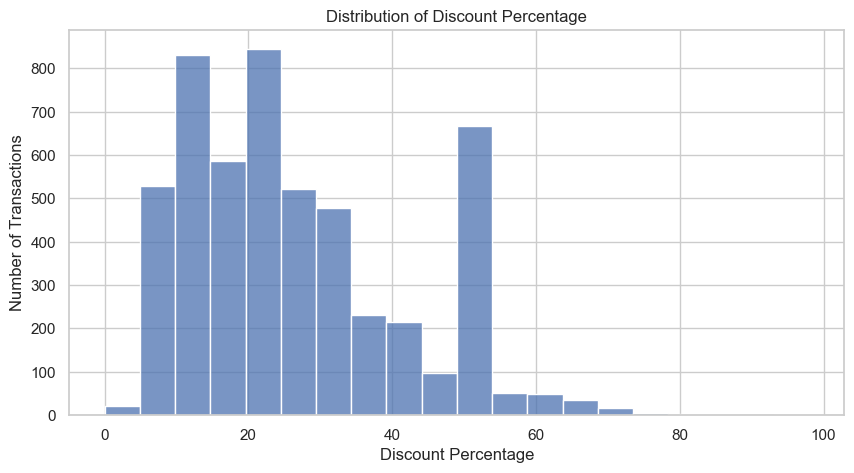

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sales_clean["Discount_Percentage"].dropna(),
    bins=20
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Transactions")

plt.show()

### 7.9 Initial Business Observations

Based on the overall sales metrics and discount distribution,
we can identify the general pricing and discounting pattern
of the retail dataset.

The detailed business insights will be developed further through
category, brand, product, inventory, customer, payment, and store
analysis.

## 8. Category Analysis

Category-level analysis helps us understand which product categories
generate higher sales and how discounting varies across categories.

We will analyze:
- Sales by Category
- Discount by Category
- Average Discount by Category

In [ ]:
category_sales = (
    sales_clean.groupby("Category")["Discounted_Value"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

Category
 Cooking Oil            91159.0
Cookware & Serveware    74272.0
Specials                67327.0
Beverages               56186.0
Skin Care               55590.0
Home Appliances         52472.0
Hair Care               46810.0
Face Care               41617.0
Bed & Bath              38965.0
Kitchen Appliances      35482.0
Name: Discounted_Value, dtype: float64

### 8.1 Sales by Category

The following analysis identifies the categories contributing the
highest discounted sales value.

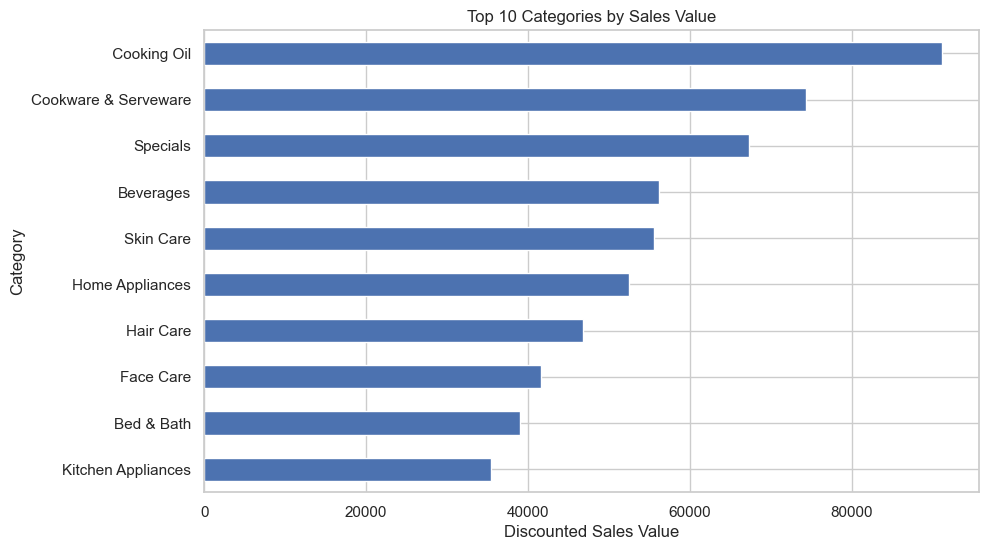

Category
 Cooking Oil            91159.0
Cookware & Serveware    74272.0
Specials                67327.0
Beverages               56186.0
Skin Care               55590.0
Home Appliances         52472.0
Hair Care               46810.0
Face Care               41617.0
Bed & Bath              38965.0
Kitchen Appliances      35482.0
Name: Discounted_Value, dtype: float64

In [ ]:
plt.figure(figsize=(10, 6))

category_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Categories by Sales Value")
plt.xlabel("Discounted Sales Value")
plt.ylabel("Category")

plt.show()


category_sales.head(10)

### 8.2 Average Discount by Category

This analysis compares the average discount percentage across
categories to identify categories with relatively higher discounting.

In [ ]:
category_discount = (
    sales_clean.groupby("Category")["Discount_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

category_discount.head(10)

Category
Geep             61.865712
Smartwatches     58.343057
Butterfly        57.467860
Zebronics        56.750757
Backpacks        51.732478
Uncategorized    50.005771
Pigeon           49.958275
Wonderchef       49.075472
Appliances       43.900902
Syska            43.804756
Name: Discount_Percentage, dtype: float64

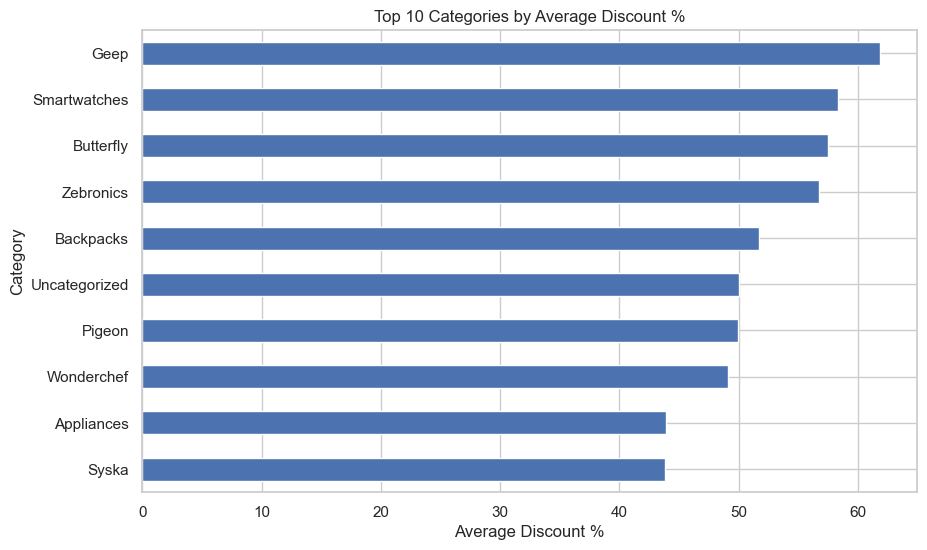

In [ ]:
plt.figure(figsize=(10, 6))

category_discount.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Categories by Average Discount %")
plt.xlabel("Average Discount %")
plt.ylabel("Category")

plt.show()

## 9. Brand Analysis

Brand-level analysis helps identify the brands contributing the most
to sales and understand differences in discounting.

In [ ]:
brand_sales = (
    sales_clean.groupby("Brand")["Discounted_Value"]
    .sum()
    .sort_values(ascending=False)
)

brand_sales.head(10)

Brand
unbranded           64605.0
Zeel                27037.0
Philips             23444.0
Prestige            22860.0
Faces Canada        22729.0
Bajaj               21977.0
Crompton Greaves    18847.0
Usha                17570.0
Lakme               17053.0
Premia              16235.0
Name: Discounted_Value, dtype: float64

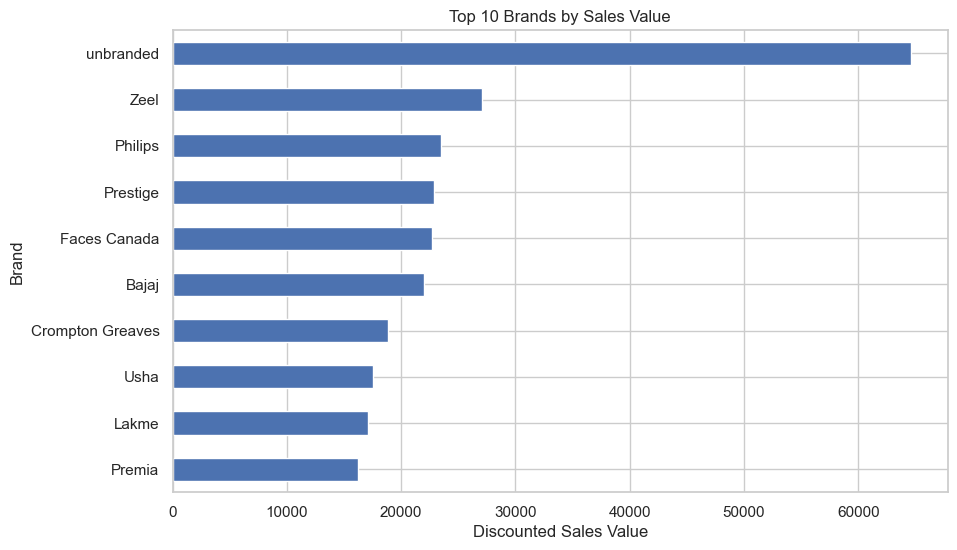

In [ ]:
plt.figure(figsize=(10, 6))

brand_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Brands by Sales Value")
plt.xlabel("Discounted Sales Value")
plt.ylabel("Brand")

plt.show()

### 9.2 Average Discount by Brand

This analysis identifies brands with the highest average
discount percentage across their transactions.

In [ ]:
brand_discount = (
    sales_clean.groupby("Brand")["Discount_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

brand_discount.head(10)

Brand
Dr.WaterR     76.717812
Raymond       66.698428
Dinesmart     65.666041
Bertolli      65.021674
Paras         64.275466
VIP           64.008404
Killer        63.197026
Aristocrat    62.837209
Naagin        61.955556
Dr. WaterR    61.872910
Name: Discount_Percentage, dtype: float64

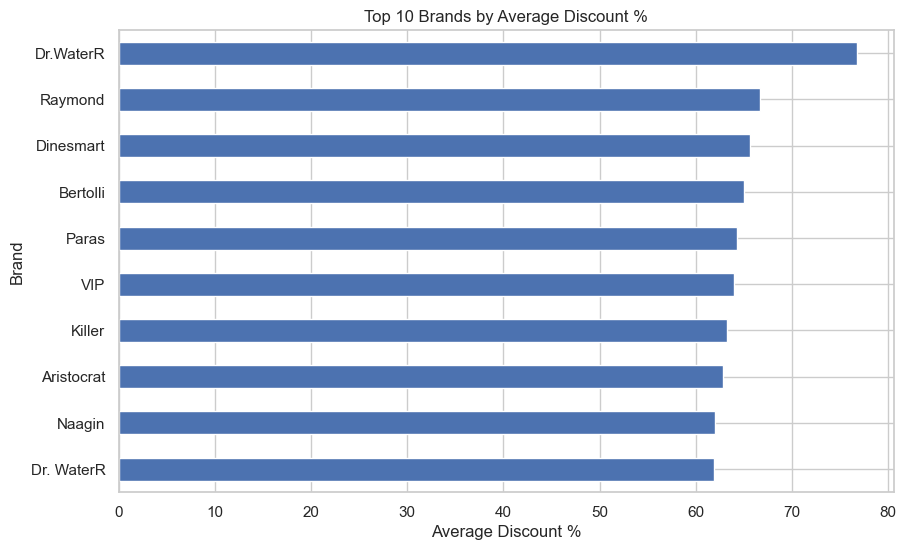

In [ ]:
plt.figure(figsize=(10, 6))

brand_discount.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Brands by Average Discount %")
plt.xlabel("Average Discount %")
plt.ylabel("Brand")

plt.show()

## 10. Product Analysis

Product-level analysis identifies the individual products
contributing the most to sales value and discount amounts.

In [ ]:
product_sales = (
    sales_clean.groupby("Product_Name")["Discounted_Value"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Product_Name
Philips UV-C Disinfection System                         7999.0
Hawkins Classic Pressure Cooker - CL50                   6829.0
Godrej Goldilocks Personal White Locker                  4999.0
Figaro Olive Oil Tin                                     4751.0
Bathla Advance 5 Step Ladder-Orange                      4699.0
Bathla Advance 4 Step Ladder-Orange                      4149.0
Morphy Richards Primo Classique Mixer Grinder - 750 W    3999.0
Saffola Gold Oil                                         3998.0
RRO Primio Refined Groundnut Oil                         3904.0
Crompton Instant Water Heater                            3899.0
Name: Discounted_Value, dtype: float64

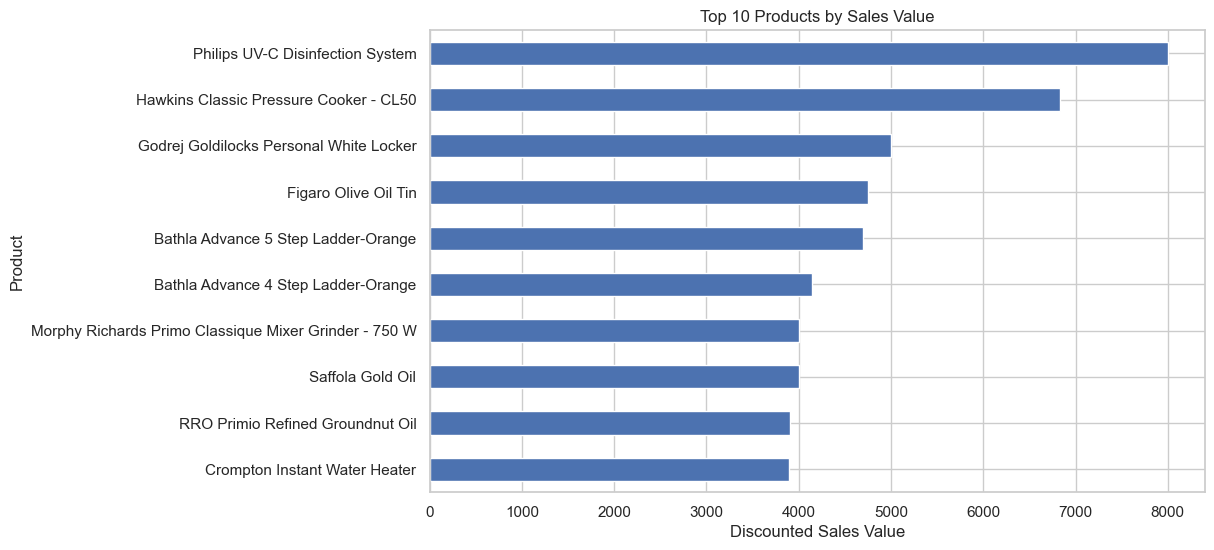

In [ ]:
plt.figure(figsize=(10, 6))

product_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales Value")
plt.xlabel("Discounted Sales Value")
plt.ylabel("Product")

plt.show()

### 10.2 Top Products by Discount Amount

This analysis identifies the products receiving the highest
total monetary discounts.

In [ ]:
product_discount = (
    sales_clean.groupby("Product_Name")["Discount_Amount"]
    .sum()
    .sort_values(ascending=False)
)

product_discount.head(10)

Product_Name
Butterfly Stainless Steel Outer Lid Curve Cooker    4899.0
Bathla Advance 5 Step Ladder-Orange                 4300.0
Borges Extra Light Olive Oil                        4252.0
Portronics Kronos Y1 Smart Watch - Grey             3500.0
Wonderchef Nutri-Blend Red With 3 Jars              3101.0
Philips UV-C Disinfection System                    2991.0
Boat Black Stone 650R Bluetooth Speaker             2991.0
Bajaj GX8 Mixer Grinder - 750 W                     2676.0
Godrej Goldilocks Personal White Locker             2670.0
Bathla Advance 4 Step Ladder-Orange                 2650.0
Name: Discount_Amount, dtype: float64

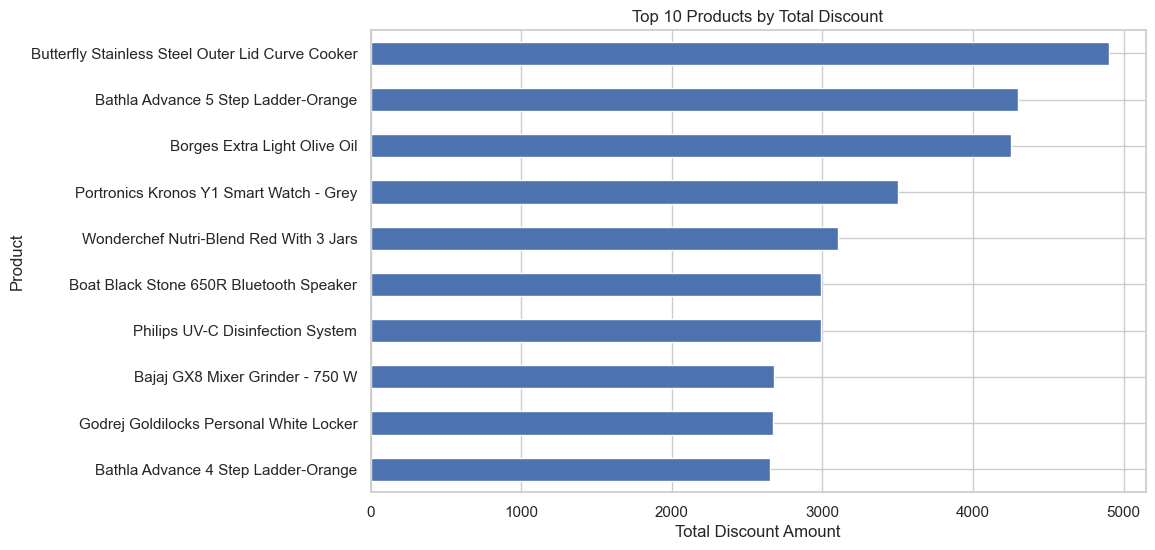

In [ ]:
plt.figure(figsize=(10, 6))

product_discount.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Discount")
plt.xlabel("Total Discount Amount")
plt.ylabel("Product")

plt.show()

## 11. Business Insights

The Python analysis provides several useful observations about
DMart's retail sales, pricing, discounting, categories, brands,
and products.

### Key Findings

- Category-level analysis identifies the strongest categories
  based on discounted sales value.
- Brand-level analysis highlights the brands contributing the
  highest sales value.
- Product-level analysis identifies the products generating
  the highest sales value.
- Discount analysis helps identify categories and brands with
  relatively higher discounting.
- The overall discount distribution shows the general pricing
  and promotional pattern across transactions.
- Data-quality checks identified missing values and one zero-price transaction; two records were excluded from the final sales analysis dataset.

### Business Recommendation

The analysis can support retail decision-making by helping
identify high-performing categories and products, evaluate
discounting patterns, and understand where pricing strategies
may have the greatest impact.

## 12. Conclusion

This Python project demonstrates a practical data-analysis
workflow using Pandas, NumPy, Matplotlib, and Seaborn.

The analysis covered:

- Data loading
- Data inspection
- Data-quality validation
- Data cleaning
- Basic feature engineering
- Overall sales analysis
- Category analysis
- Brand analysis
- Product analysis
- Business insights

The Python analysis complements the SQL and Power BI components
of the DMart Retail Analytics project and provides an additional
perspective on the underlying retail data.

## 13. Cross-Validation with SQL and Power BI

Before finalizing the project, key metrics from the Python
analysis are cross-checked against the SQL and Power BI analysis.

This helps identify differences caused by data versions,
cleaning decisions, or calculation methods.

In [ ]:
print("Python Cross-Validation Metrics")
print("-" * 40)

print("Transactions:", len(sales_clean))
print("Total Sales: ₹", round(sales_clean["Discounted_Price"].sum(), 2))
print("Total Discount: ₹", round(sales_clean["Discount_Amount"].sum(), 2))
print("Average Selling Price: ₹", round(sales_clean["Discounted_Price"].mean(), 2))
print("Average Discount %:", round(sales_clean["Discount_Percentage"].mean(), 2))

Python Cross-Validation Metrics
----------------------------------------
Transactions: 5187
Total Sales: ₹ 1227842.5
Total Discount: ₹ 556987.01
Average Selling Price: ₹ 236.72
Average Discount %: 26.39


In [ ]:
print("Python dataset before cleaning:", len(sales))
print("Python dataset after cleaning:", len(sales_clean))
print("Records removed:", len(sales) - len(sales_clean))

Python dataset before cleaning: 5189
Python dataset after cleaning: 5187
Records removed: 2


In [ ]:
removed_records = sales.loc[~sales["sales_transaction_id"].isin(sales_clean["sales_transaction_id"])]

print("Records removed during cleaning:")
print(removed_records)

Records removed during cleaning:
      sales_transaction_id                               Product_Name  \
2230                  2231           Kopiko Cappuccino Coffee Candies   
4323                  4324  Elle 18 Nail Pops Nail Colour - Shade 125   

        Brand  Price  Discounted_Price Quantity   Category  
2230   Kopiko    0.0               0.0   140 gm     Sweets  
4323  Elle 18    NaN               NaN     5 ml  Nail Care  
